<a href="https://colab.research.google.com/github/AnIsAsPe/Recomendaci-n-de-libros-usando-LDA/blob/main/Notebooks/Recomendaci%C3%B3n_de_libros_usando_LDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h2> Problema:

Se quiere construir un sistema de recomendación de libros basado en los resumentes de los libros y los temas (topicos) de los mismos.

Para tal fin, se utiliza el [CMU Book Summary Dataset](https://www.cs.cmu.edu/~dbamman/booksummaries.html)

# Bibliotecas y funciones

In [1]:
!pip install --upgrade numpy==1.26.4


In [2]:
!pip install pyLDAvis  #biblioteca que extrae información de un modelo LDA para obtener una visualización interactiva

  Using cached pyLDAvis-3.4.1-py3-none-any.whl.metadata (4.2 kB)
  Using cached funcy-2.0-py2.py3-none-any.whl.metadata (5.9 kB)
  Using cached gensim-4.4.0-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (8.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.4 MB/s eta 0:00:00


In [3]:
# Para leer los datos
import csv
import json

import pandas as pd
import numpy as np
from collections import Counter # para contar frecuencias

# preprocesar texto
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Modelado de tópicos
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import pyLDAvis
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) # al instalar pyLDAvis ocasiona un warning con ipkernel

In [4]:
import sklearn

for lib in [sklearn, pyLDAvis, np, pd]:
  print(lib.__name__, lib.__version__)

sklearn 1.6.1
pyLDAvis 3.4.0
numpy 1.26.4
pandas 2.2.2


In [5]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# Lectura y exploración de datos

In [6]:
!curl -o "/content/booksummaries.tar.gz" "https://raw.githubusercontent.com/AnIsAsPe/Recomendaci-n-de-libros-usando-LDA/refs/heads/main/Datos/booksummaries.tar.gz"
!tar -xzvf "/content/booksummaries.tar.gz" -C"/content/"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 16.0M  100 16.0M    0     0  11.4M      0  0:00:01  0:00:01 --:--:-- 11.5M
booksummaries/
booksummaries/README
booksummaries/booksummaries.txt


In [7]:
data = []

with open("/content/booksummaries/booksummaries.txt", 'r') as f:
    reader = csv.reader(f, dialect='excel-tab')
    for row in reader:
        data.append(row)

In [8]:
len(data)

16559

In [9]:
data[3]

['1756',
 '/m/0sww',
 'An Enquiry Concerning Human Understanding',
 'David Hume',
 '',
 '',
 ' The argument of the Enquiry proceeds by a series of incremental steps, separated into chapters which logically succeed one another. After expounding his epistemology, Hume explains how to apply his principles to specific topics. In the first section of the Enquiry, Hume provides a rough introduction to philosophy as a whole. For Hume, philosophy can be split into two general parts: natural philosophy and the philosophy of human nature (or, as he calls it, "moral philosophy"). The latter investigates both actions and thoughts. He emphasizes in this section, by way of warning, that philosophers with nuanced thoughts will likely be cast aside in favor of those whose conclusions more intuitively match popular opinion. However, he insists, precision helps art and craft of all kinds, including the craft of philosophy. Next, Hume discusses the distinction between impressions and ideas. By "impressio

In [10]:
title = []
author = []
summary = []
for i in range(len(data)):
  title.append(data[i][2])
  author.append(data[i][3])
  summary.append(data[i][6])

datos = pd.DataFrame({ 'Title': title, 'Author': author,
                    'Summary': summary})
print(datos.shape)
datos.head(3)


(16559, 3)


,Title,Author,Summary
0,Animal Farm,George Orwell,"Old Major, the old boar on the Manor Farm, ca..."
1,A Clockwork Orange,Anthony Burgess,"Alex, a teenager living in near-future Englan..."
2,The Plague,Albert Camus,The text of The Plague is divided into five p...


In [11]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16559 entries, 0 to 16558
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Title    16559 non-null  object
 1   Author   16559 non-null  object
 2   Summary  16559 non-null  object
dtypes: object(3)
memory usage: 388.2+ KB


In [12]:
datos[['Title', 'Author']].nunique()


,0
Title,16277
Author,4715


In [13]:
datos.Title.value_counts().head()

,count
Title,
Nemesis,6
Outcast,4
Haunted,4
Inferno,4
The Gift,3


 ¿por qué hay más de un resumen para cada titulo?

In [14]:
datos[datos.Title=='Nemesis']

,Title,Author,Summary
375,Nemesis,Isaac Asimov,The novel is set in an era in which interstel...
3499,Nemesis,Agatha Christie,Miss Marple receives a post card from the rec...
5157,Nemesis,Scott Ciencin,One of Fred's old friends from graduate schoo...
6159,Nemesis,Jo Nesbø,A bank robbery is committed by a lone robber ...
13696,Nemesis,Philip Roth,Nemesis explores the effect of a 1944 polio e...
13842,Nemesis,,"The story, set in Latium in AD 77, opens with..."


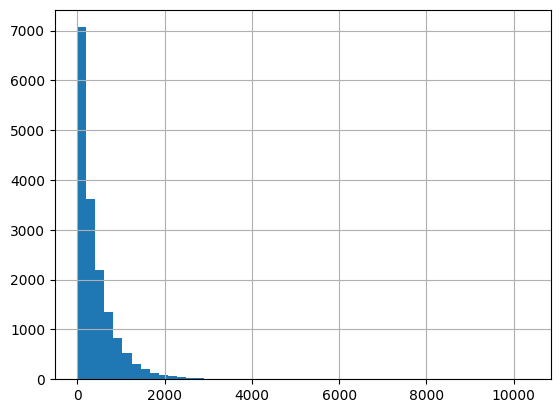

In [15]:
datos['len Summary'] = datos['Summary'].apply(lambda x: len(str(x).split()))
datos['len Summary'].hist(bins=50)
plt.show()

In [16]:

datos['len Summary'].describe(percentiles=[0.025, 0.05,0.10, 0.25,0.50, 0.75,0.90, 0.95, 0.975])

,len Summary
count,16559.000000
mean,429.202126
std,500.339692
min,1.000000
2.5%,29.000000
5%,44.000000
10%,64.000000
25%,120.000000
50%,263.000000
75%,569.000000


In [17]:
# Incluiremos en el dataset solamente resumentes con más de 30 palabras y menos de 1313 (sacrificando 7.5% de los datos)
quantile_025 = datos['len Summary'].quantile(0.025)
quantile_095 = datos['len Summary'].quantile(0.95)
filtro = (datos['len Summary'] > quantile_025) & (datos['len Summary'] < quantile_095)
df = datos[filtro].copy().reset_index(drop=True)
df.shape

(15297, 4)

# Obtener los tópicos principales

## Vectorización de textos

In [18]:
st = PorterStemmer()
stop_words = re.compile(r'\b(' + r'|'.join(stopwords.words('english')) + r')\b\s*')

def preprocesar(texto):
      # Convierte a minúsculas
      texto = (texto).lower()

      # Elimina stopwords
      texto = stop_words.sub('', texto)
      # Elimina puntuación y números
      texto = re.sub('[^a-z]+', ' ', texto)

      # Normalización y eliminación palabras que tengan menos de tres caracteres
      texto = texto.split()
      stemmed_words = [st.stem(i) for i in texto if len(i)>2]
      texto = ' '.join(stemmed_words)

      return(texto)

In [19]:
df['Summary_pp'] = df['Summary'].apply(preprocesar)
df.head()

,Title,Author,Summary,len Summary,Summary_pp
0,Animal Farm,George Orwell,"Old Major, the old boar on the Manor Farm, ca...",957,old major old boar manor farm call anim farm m...
1,A Clockwork Orange,Anthony Burgess,"Alex, a teenager living in near-future Englan...",998,alex teenag live near futur england lead gang ...
2,The Plague,Albert Camus,The text of The Plague is divided into five p...,1119,text plagu divid five part town oran thousand ...
3,A Fire Upon the Deep,Vernor Vinge,The novel posits that space around the Milky ...,722,novel posit space around milki way divid conce...
4,All Quiet on the Western Front,Erich Maria Remarque,"The book tells the story of Paul Bäumer, a Ge...",770,book tell stori paul umer german soldier urg s...


In [92]:
vectorizer = CountVectorizer(ngram_range=(1,3),   # Al usar unigramas, bigramas y tigramas, el vocabulario crecerá mucho
                             min_df=5,            # para filtrar palabras que aparecen muy pocas veces
                             max_df =0.4,         # para filtrar palabras demasiado frecuentes
                             max_features = 5000  # para filtrar el ruido
                             )
BOW = vectorizer.fit_transform(df['Summary_pp'])
BOW.shape

(15297, 5000)

In [93]:
vocabulario = vectorizer.get_feature_names_out()
len(vocabulario)

5000

In [98]:
np.random.choice(vocabulario, 100, replace=False)


array(['verg', 'thorn', 'twenti year', 'expens', 'check', 'massachusett',
       'infatu', 'lifelong', 'subdu', 'inadvert', 'drew', 'tendenc',
       'submarin', 'bu', 'lizard', 'scream', 'humor', 'return earth',
       'depress', 'foundat', 'imposs', 'cambridg', 'judgment', 'sale',
       'driven', 'riot', 'manor', 'foe', 'barley', 'hope', 'long term',
       'injuri', 'calli', 'sport', 'mistak', 'oil', 'point view', 'finn',
       'fugit', 'nois', 'delight', 'illus', 'dwell', 'leav', 'hate',
       'smell', 'bajir', 'kim', 'five', 'castl', 'reluctantli', 'beatric',
       'anderson', 'kingdom', 'circumst', 'gentl', 'clean', 'chose',
       'liter', 'cannib', 'henc', 'cart', 'less', 'made', 'theft',
       'upper', 'beat', 'iren', 'cathi', 'record', 'pleasant', 'bitter',
       'second time', 'size', 'heal', 'declar', 'gabriel', 'schedul',
       'year pass', 'matthew', 'junior', 'establish', 'wealth', 'induc',
       'ongo', 'lori', 'led', 'elabor', 'eccentr', 'face', 'carlo',
      

## Entrenamiento del modelo

El número óptimo de topicos depende de las caracteristicas del texto a analizar (el largo de los textos, la cantidad de distintas ideas)

No obstante existen algunas metricas que ayudan a determinar k.

In [99]:
k = 8

In [82]:

lda_model = LatentDirichletAllocation(n_components=k, learning_method='online',
                                      random_state=42,
                                      max_iter=5
                                      )

In [83]:
%%time
lda_model.fit(BOW) # entrena el modelo y obtienela matriz documento-topico

CPU times: user 4min 10s, sys: 198 ms, total: 4min 11s
Wall time: 4min 28s


LatentDirichletAllocation(learning_method='online', max_iter=30, n_components=8,
                          random_state=42)

In [85]:
lda_model.perplexity(BOW) # K=8

1968.4489853005205

### Guardamos modelo

In [102]:
import pickle
path = '/content/drive/MyDrive/Modelos/modelosLDA/LDA Books/'
tuple_models = (lda_model, BOW, vectorizer)
pickle.dump(tuple_models, open (path + "tuple_model_books_v5k_k8.pkl", 'wb'))

In [103]:
import pickle
path = '/content/drive/MyDrive/Modelos/modelosLDA/LDA Books/'
lda_model, BOW, vectorizer = pickle.load(open(path + "tuple_model_books_v5k_k8.pkl", 'rb'))


### Distribución de temas en cada resumen  ($β$)  n x k

In [104]:
doc_top = pd.DataFrame(lda_model.transform(BOW))
print(doc_top.shape)
doc_top.head()

(15297, 8)


,0,1,2,3,4,5,6,7
0,0.026194,0.310793,0.095466,0.176339,0.019598,0.295661,0.043049,0.032900
1,0.040594,0.208532,0.024640,0.228863,0.253786,0.146837,0.017037,0.079712
2,0.123031,0.276793,0.051515,0.202793,0.087811,0.094696,0.048991,0.114370
3,0.128212,0.190663,0.403105,0.126334,0.069019,0.000370,0.000369,0.081928
4,0.020985,0.227921,0.087776,0.298685,0.034790,0.110600,0.039987,0.179256


In [105]:
doc_top.sum(axis=1)

,0
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
15292,1.0
15293,1.0
15294,1.0
15295,1.0


In [106]:
df_lda = pd.merge(df, doc_top, left_index=True, right_index=True)
df_lda.head(2)

,Title,Author,Summary,len Summary,Summary_pp,0,1,2,3,4,5,6,7
0,Animal Farm,George Orwell,"Old Major, the old boar on the Manor Farm, ca...",957,old major old boar manor farm call anim farm m...,0.026194,0.310793,0.095466,0.176339,0.019598,0.295661,0.043049,0.032900
1,A Clockwork Orange,Anthony Burgess,"Alex, a teenager living in near-future Englan...",998,alex teenag live near futur england lead gang ...,0.040594,0.208532,0.024640,0.228863,0.253786,0.146837,0.017037,0.079712


### Distribución de palabras en cada tema ($\theta$) k x d

In [107]:
word_distribution_topic = lda_model.components_ /lda_model.components_.sum(axis=1)[:, np.newaxis]
θs = pd.DataFrame(word_distribution_topic,
                         columns=vocabulario)
print(θs.shape)
θs

(8, 5000)


,aaron,abandon,abbey,abbot,abduct,abel,abil,abl,aboard,aborigin,...,youth,yuuzhan,yuuzhan vong,zero,zeu,zoe,zoey,zombi,zone,zoo
0,5.311017e-07,0.000391,8.447178e-04,3.438646e-04,2.791438e-04,5.303188e-07,1.402009e-05,0.000686,6.294767e-05,5.302552e-07,...,3.946280e-04,5.299069e-07,5.299118e-07,5.301901e-07,3.328542e-04,5.302562e-07,5.299531e-07,5.301809e-07,5.304679e-07,5.305628e-07
1,3.353703e-07,0.000189,3.352625e-07,3.350956e-07,3.356950e-07,3.350321e-07,6.604318e-04,0.000324,3.351104e-07,5.799232e-05,...,4.574744e-04,3.348965e-07,3.348952e-07,9.112644e-05,3.353111e-07,3.352967e-07,3.349585e-07,3.353090e-07,5.005379e-05,3.355284e-07
2,4.344660e-07,0.000887,4.337305e-07,4.341321e-07,1.494213e-04,4.334573e-07,8.026518e-04,0.002164,1.533549e-03,2.142654e-04,...,4.341258e-07,4.337190e-07,4.337211e-07,1.915968e-04,4.338588e-07,4.336989e-07,4.336464e-07,5.534902e-04,6.308972e-04,2.910961e-04
3,2.948130e-05,0.000767,2.552576e-07,2.551559e-07,3.401069e-07,2.396418e-05,5.052680e-05,0.000887,2.552143e-07,2.555519e-07,...,3.476916e-04,2.549745e-07,2.549750e-07,2.553378e-07,2.552615e-07,2.556539e-07,2.551573e-07,2.552266e-07,2.553694e-07,6.409801e-05
4,2.484002e-04,0.000066,5.832785e-07,5.830649e-07,3.812504e-04,5.837404e-07,5.761490e-05,0.000801,1.037759e-04,5.837212e-07,...,5.834705e-07,4.865561e-04,4.434061e-04,9.135787e-05,5.837881e-07,5.831875e-07,5.826822e-07,6.009129e-07,4.034714e-05,5.842713e-07
5,2.884083e-07,0.000315,2.887644e-07,2.885012e-07,1.088589e-04,2.883511e-07,1.322846e-04,0.000705,2.884745e-07,2.889855e-07,...,2.847907e-06,2.881124e-07,2.881131e-07,2.886425e-07,1.765360e-05,2.890614e-07,4.850698e-04,2.884715e-07,2.884083e-07,2.904328e-07
6,2.251616e-04,0.000495,5.272338e-07,5.272583e-07,1.602786e-04,5.616333e-04,1.948970e-03,0.001992,5.271370e-07,5.273510e-07,...,1.383621e-04,5.266848e-07,5.266786e-07,5.270893e-07,5.276572e-07,4.996675e-04,5.276810e-07,3.007591e-04,5.268284e-07,5.280240e-07
7,6.729843e-07,0.000290,6.723081e-07,6.717295e-07,4.218568e-05,6.724022e-07,6.722360e-07,0.000093,1.273584e-04,6.745642e-07,...,1.960267e-04,6.713478e-07,6.713479e-07,6.725063e-07,6.719235e-07,6.721144e-07,6.713783e-07,6.721278e-07,6.726328e-07,1.072961e-04


In [108]:
θs.sum(axis=1)

,0
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
5,1.0
6,1.0
7,1.0


In [110]:
for top in range(8):
  print('\nPalabras más frecuentes del topico {}'.format(top))
  tokMasFrec = θs.T.loc[:,top].sort_values(ascending=False).head(10).index
  for tok in tokMasFrec:
      print(tok)


Palabras más frecuentes del topico 0
king
retriev
somewher
kill
tail
sink
loos
primit
father
ladi

Palabras más frecuentes del topico 1
book
notion
store
charact
oliv
lieuten
also
first book
chapter
world

Palabras más frecuentes del topico 2
shine
human be
earn
plane
time
oliv
use
destini
forc leav
creek

Palabras más frecuentes del topico 3
famili
father
mostli
year
louisa
becom
lieuten
littl girl
friend famili
scholarship

Palabras más frecuentes del topico 4
multipl
kill
invis
pole
case
dean
agent
find father
oliv
work

Palabras más frecuentes del topico 5
find father
get away
tell
oliv
dawn
back
hous find
tail
combin
leav

Palabras más frecuentes del topico 6
powder
kill
find father
world
maggi
oliv
cite
help find
drag
use

Palabras más frecuentes del topico 7
war
american
jacki
store
john
harriet
british
never seen
germani
herald


### Visualización del modelo

In [111]:
import pyLDAvis.lda_model
pyLDAvis.enable_notebook()

prepared_data = pyLDAvis.lda_model.prepare(lda_model, BOW, vectorizer)
display(prepared_data)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
3      0.055323  0.126073       1        1  19.498169
1     -0.095976 -0.092062       2        1  19.272776
5      0.136901  0.084304       3        1  14.462721
2      0.000435 -0.137436       4        1  12.735207
0      0.070679  0.041850       5        1   9.637242
7     -0.189197  0.126969       6        1   9.073057
4     -0.066015 -0.044994       7        1   8.180588
6      0.087850 -0.104704       8        1   7.140240, topic_info=            Term         Freq        Total Category  logprob  loglift
2942     multipl  4002.000000  4002.000000  Default  30.0000  30.0000
4010       shine  3998.000000  3998.000000  Default  29.0000  29.0000
4831         war  5513.000000  5513.000000  Default  28.0000  28.0000
2461        kill  7949.000000  7949.000000  Default  27.0000  27.0000
2467        king  3137.000000  3137.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
1760   forc leav   689.363696  5156.406063   Topic8  -5.5429   0.6272
430        begin   707.950879  7103.647812   Topic8  -5.5163   0.3334
2582     lieuten   698.766984  8977.630695   Topic8  -5.5294   0.0862
2611  littl girl   691.676692  7483.580171   Topic8  -5.5396   0.2581
1490       escap   670.742364  4341.821122   Topic8  -5.5703   0.7718

[683 rows x 6 columns], token_table=      Topic      Freq    Term
term                         
2         5  0.996870   abbey
8         4  0.882018  aboard
8         5  0.027449  aboard
8         6  0.051238  aboard
8         7  0.038428  aboard
...     ...       ...     ...
4979      6  0.118846   young
4979      7  0.016006   young
4979      8  0.067026   young
4995      8  0.989928     zoe
4996      3  0.994805    zoey

[1939 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[4, 2, 6, 3, 1, 8, 5, 7])

## Sistema de recomendación usando similitud coseno


<p align="center">
  <img src="https://drive.google.com/uc?export=view&id=1t6gQrFy1UMe_GtuGNDND90MqcebTeJD_" width="45%">
</p>

.

$$\text{similitud coseno}(A, B) = \frac{\sum_{i=1}^{n} A_i B_i}{\sqrt{\sum_{i=1}^{n} A_i^2} ~~~\sqrt{\sum_{i=1}^{n} B_i^2}}$$

In [87]:

def similitud_coseno(a_vector, b_vector):
    '''Calcula la similitud coseno entre los vectores a y b'''

    numerador = np.dot(a_vector, b_vector)

    a_norm = np.sqrt(np.sum(a_vector**2))
    b_norm = np.sqrt(np.sum(b_vector**2))

    denominador = a_norm * b_norm

    similitud_coseno = numerador / denominador

    return similitud_coseno

In [88]:
def documentos_similares(titulo):
  inx = df[df['Title']==titulo].index[0]
  q_k = doc_top.loc[inx].values
  n = doc_top.shape[0]
  similaridad = {}
  relevantes={}

  # Calcular similitud coseno
  for doc_inx in range(n):
      if doc_inx == inx:
          continue
      similaridad[doc_inx] = similitud_coseno(q_k, doc_top.loc[doc_inx].values)

  rank = {k:v for k,v in sorted(similaridad.items(), key=lambda x: x[1],
                                reverse=True)}
  top5= pd.DataFrame.from_dict(rank, orient = 'index', columns=['sim_cos']).head()
  recomendaciones = pd.merge(df.iloc[:,0:3], top5, how='right',  right_index=True, left_index=True)
  recomendaciones.index = np.arange(1, 6)

  return recomendaciones



In [89]:
documentos_similares('Dune')

,Title,Author,Summary,sim_cos
1,Renegade of Callisto,Lin Carter,In the final adventure set on the Jovian moon...,0.977969
2,Chapterhouse Dune,Frank Herbert,The situation is desperate for the Bene Gesse...,0.976335
3,The Call of Earth,Orson Scott Card,The book focuses on several key events that h...,0.975238
4,Eye of the Storm,John Ringo,"Michael O'Neal, now a general in charge of re...",0.971526
5,The Forest King,Paul B. Thompson,"After the trial of Vedvedsica, General Balif ...",0.968878


In [90]:
documentos_similares('The Time Machine')

,Title,Author,Summary,sim_cos
1,Big Planet,Jack Vance,Big Planet had been colonized hundreds of yea...,0.993375
2,The Secret Sharer,Robert Silverberg,*Nameless Captain (Narrator) *Leggatt *Captai...,0.992658
3,The Houses of Iszm,Jack Vance,"The inhabitants of a planet called Iszm, a sp...",0.992073
4,A Walk in the Sun,Geoffrey A. Landis,"The story follows Trish, the only survivor of...",0.990401
5,The Science of Discworld,,The Discworld part of the book begins when a ...,0.990032
